In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
import bagpipes as pipes
from bagpipes import model_galaxy 
os.chdir("/Users/christine/FA26_1501")

In [5]:
model_components = {}
model_components["redshift"] = 0 # Observed redshift (mandatory)
model_components["veldisp"] = 300 # Max age of birth clouds: Gyr
model_components["t_bc"] = 0.01


# Dict containing SFH info
dblplaw = {}
dblplaw["tau"] = 12
dblplaw["alpha"] = 30
dblplaw["beta"] = 0.5
dblplaw["metallicity"] = 0.8
dblplaw["massformed"] = 11
model_components["dblplaw"] = dblplaw

dust = {}
dust["type"] = "Calzetti" #attenuation law
dust["Av"] = 0.2
dust["eta"] = 3
model_components["dust"] = dust

nebular = {}
nebular["logU"] = -3
model_components["nebular"] = nebular

In [6]:
print(model_components)
wavelength_grid = np.arange(2000, 7005, 5) # units A


{'redshift': 0, 'veldisp': 300, 't_bc': 0.01, 'dblplaw': {'tau': 12, 'alpha': 30, 'beta': 0.5, 'metallicity': 0.8, 'massformed': 11}, 'dust': {'type': 'Calzetti', 'Av': 0.2, 'eta': 3}, 'nebular': {'logU': -3}}


In [7]:
model = model_galaxy(model_components, filt_list=None, spec_wavs=wavelength_grid, spec_units='ergscma', phot_units='ergscma', index_list=None)

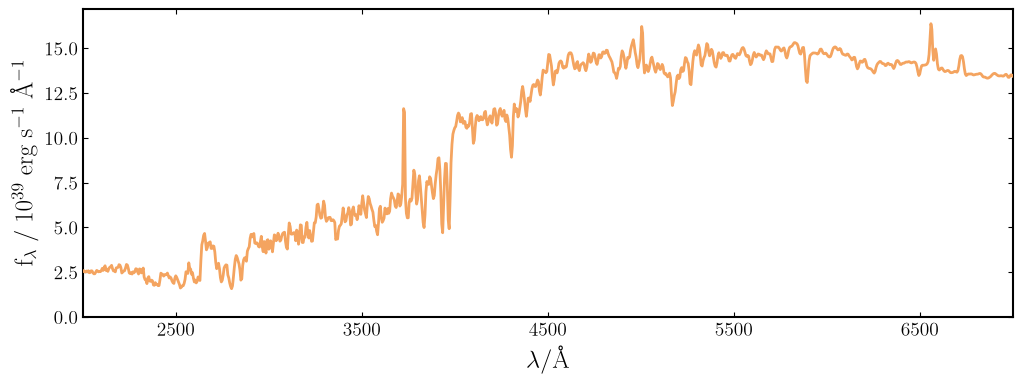

(<Figure size 1200x400 with 1 Axes>,
 [<Axes: xlabel='$\\lambda / \\mathrm{\\AA}$', ylabel='$\\mathrm{f_{\\lambda}}\\ \\mathrm{/\\ 10^{39}\\ erg\\ s^{-1}\\ \\AA^{-1}}$'>])

In [8]:
model.plot()

In [9]:
uvista_filt_list = ["filters/CFHT_MegaCam.u.dat",
                    "filters/CFHT_MegaCam.g.dat",
                    "filters/CFHT_MegaCam.r.dat",
                    "filters/CFHT_MegaCam.i.dat",
                    "filters/CFHT_MegaCam.z.dat",
                    "filters/Subaru_Suprime.z.dat",
                    "filters/Paranal_VISTA.Y.dat",
                    "filters/Paranal_VISTA.J.dat",
                    "filters/Paranal_VISTA.H.dat",
                    "filters/Paranal_VISTA.Ks.dat",
                    "filters/Spitzer_IRAC.I1.dat",
                    "filters/Spitzer_IRAC.I2.dat"]

In [10]:
model = model_galaxy(model_components, filt_list=uvista_filt_list, spec_wavs=wavelength_grid, spec_units='ergscma', phot_units='ergscma', index_list=None)

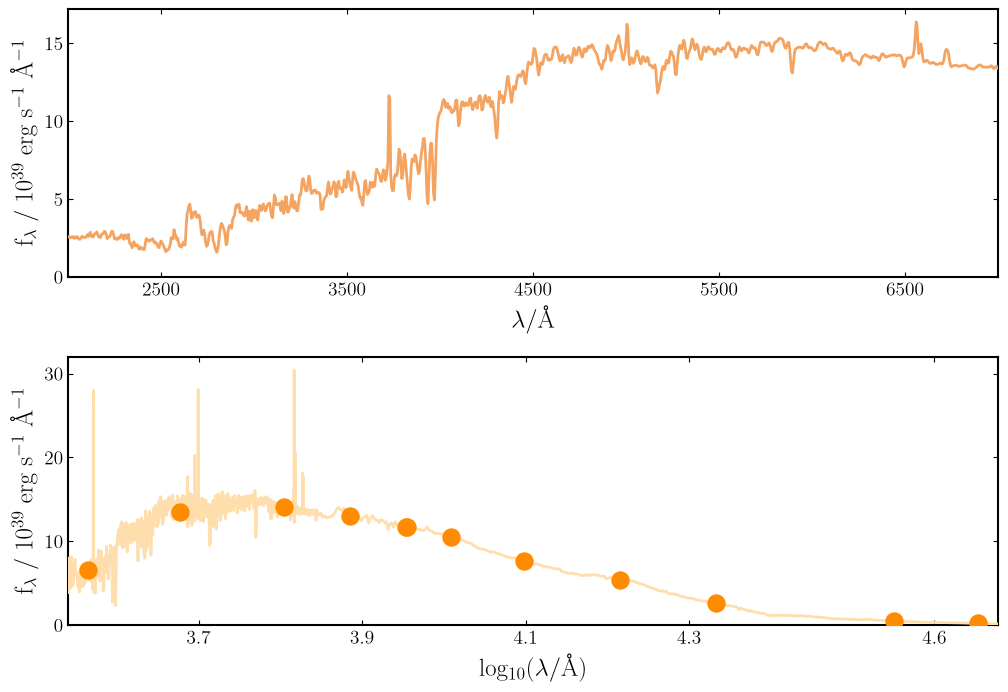

(<Figure size 1200x800 with 2 Axes>,
 [<Axes: xlabel='$\\lambda / \\mathrm{\\AA}$', ylabel='$\\mathrm{f_{\\lambda}}\\ \\mathrm{/\\ 10^{39}\\ erg\\ s^{-1}\\ \\AA^{-1}}$'>,
  <Axes: xlabel='$\\mathrm{log_{10}}\\big(\\lambda / \\mathrm{\\AA}\\big)$', ylabel='$\\mathrm{f_{\\lambda}}\\ \\mathrm{/\\ 10^{39}\\ erg\\ s^{-1}\\ \\AA^{-1}}$'>])

In [11]:
model.plot()

In [41]:
wavelength = model.spectrum[:, 0]
luminosity = model.spectrum[:, 1]

Text(0, 0.5, '$L_\\lambda\\ /\\ 10^{40}$ erg s$^{-1}$ \\AA$^{-1}$')

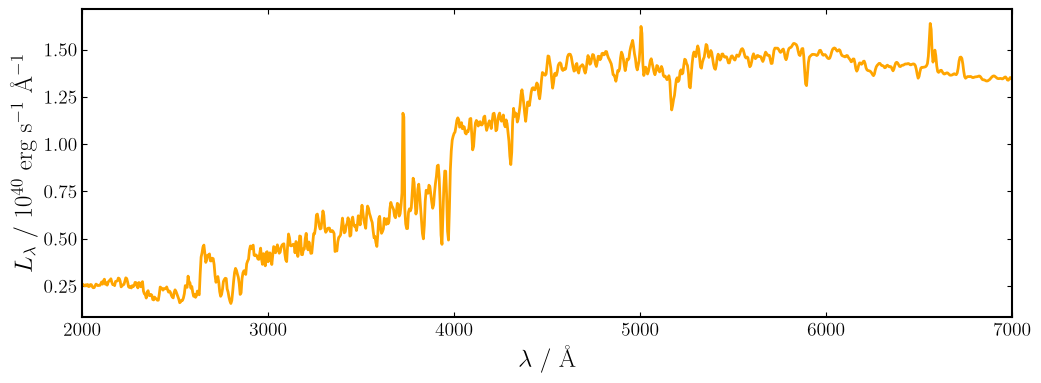

In [42]:
fig, ax = plt.subplots(figsize = (12, 4))
ax.plot(wavelength, luminosity / 10**40, color = "orange")
ax.set_xlim(np.min(wavelength), np.max(wavelength))
ax.set_xlabel(r"$\lambda$ / \AA")
ax.set_ylabel(r"$L_\lambda\ /\ 10^{40}$ erg s$^{-1}$ \AA$^{-1}$")

In [43]:
full_spec = model.spectrum_full #luminosities
wavs = model.wavelengths
photometry = model.photometry
filter_eff_wavs = model.filter_set.eff_wavs

In [44]:
model.filter_set.eff_wavs

array([ 3676.11662228,  4763.96186724,  6382.54890621,  7682.91951277,
        8979.59792107,  9028.20573155, 10210.70794043, 12525.24741425,
       16432.75560944, 21521.67036704, 35507.89739706, 44959.61362106])

In [52]:
import matplotlib.ticker as ticker

Text(0, 0.5, '$L_\\lambda\\ /\\ 10^{40}$ erg s$^{-1}$ \\AA$^{-1}$')

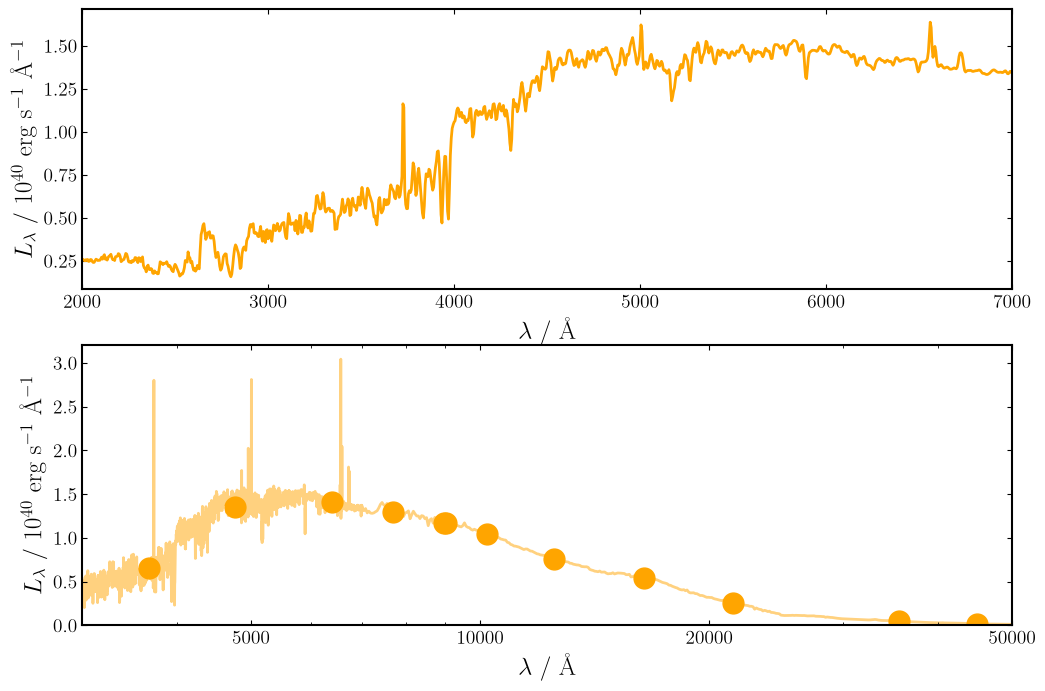

In [53]:
plt.close("all")

fig, (ax0, ax1) = plt.subplots(nrows = 2, ncols=1, figsize = (12, 8))
ax0.plot(wavelength, luminosity / 10**40, color = "orange")
ax0.set_xlim(np.min(wavelength), np.max(wavelength))
ax0.set_xlabel(r"$\lambda$ / \AA")
ax0.set_ylabel(r"$L_\lambda\ /\ 10^{40}$ erg s$^{-1}$ \AA$^{-1}$")

ax1.plot(wavs, full_spec / 10**40, color = "orange", alpha = 0.5, zorder = 1)
ax1.plot(filter_eff_wavs, photometry / 10**40, marker = 'o', color = "orange", linestyle="none", markersize= 15, zorder = 2)
ax1.set_xscale('log')
ax1.set_xlim(3000, 50000)
ax1.set_ylim(0, 3.2)
ax1.set_xticks([5000, 10000, 20000, 50000])
ax1.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax1.xaxis.set_minor_formatter(ticker.NullFormatter())
ax1.set_xlabel(r"$\lambda$ / \AA")
ax1.set_ylabel(r"$L_\lambda\ /\ 10^{40}$ erg s$^{-1}$ \AA$^{-1}$")

In [85]:
centre_stellar_age = model.sfh.ages 
SFR_bin = model.sfh.sfh
age_width = model.sfh.age_widths
age_universe = model.sfh.age_of_universe
t_form_gyr = (age_universe - centre_stellar_age) * 10**(-9)

In [65]:
centre_stellar_age.shape, SFR_bin.shape, age_width.shape, centre_stellar_age[:5], centre_stellar_age[-5:], age_universe, model.sfh.sfh[-5:]

((1654,),
 (1654,),
 (1654,),
 array([1000000.        , 1005773.06300174, 1011579.4542599 ,
        1017419.36618061, 1023292.99228076]),
 array([1.32586712e+10, 1.33352143e+10, 1.34121994e+10, 1.34896288e+10,
        1.35675053e+10]),
 np.float64(13466983947.061872),
 array([1.64336735, 1.30702641, 0.8427639 , 0.        , 0.        ]))

In [63]:
riemann = np.sum(age_width*SFR_bin)

In [64]:
riemann, 10**model.sfh.formed_mass, riemann/10**model.sfh.formed_mass

(np.float64(100000000000.00002),
 np.float64(100000000000.0),
 np.float64(1.0000000000000002))

In [ ]:
sfr_peak = np.argmax(model.sfh.sfh)
t_peak = t_form_gyr[sfr_peak] # predict_peak = 10.49


Text(0, 0.5, 'SFR / $M_\\odot \\mathrm yr^{-1}$')

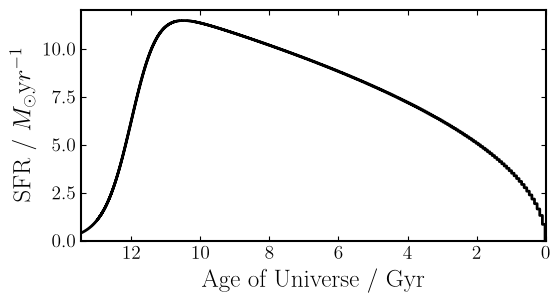

In [87]:
plt.close('all')

fig, ax = plt.subplots(figsize = (6, 3))
ax.step(t_form_gyr, SFR_bin, where="mid", color="black")
ax.set_xlim(age_universe* 10**(-9), 0)
ax.set_ylim(bottom=0)
ax.set_xlabel('Age of Universe / Gyr')
ax.set_ylabel(r'SFR / $M_\odot \mathrm yr^{-1}$')

In [82]:
print(t_form_gyr[:3])
print(np.min(t_form_gyr), np.max(t_form_gyr))

[-0.00099999 -0.00100576 -0.00101157]
-13.567505289551843 -0.000999986533016053


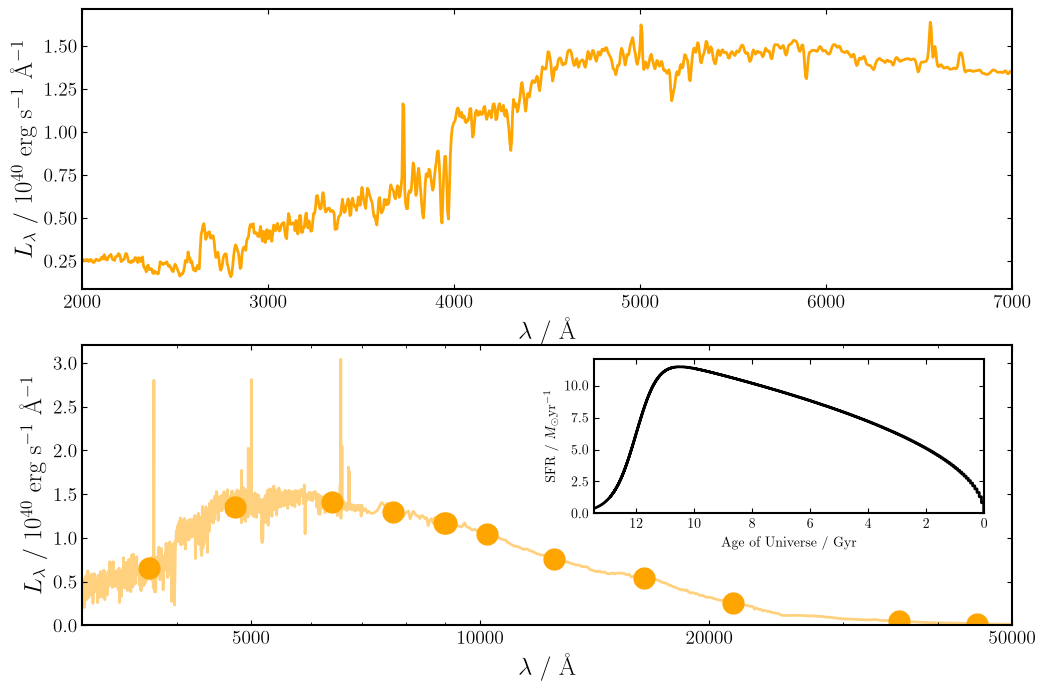

In [91]:
plt.close("all")

fig, (ax0, ax1) = plt.subplots(nrows = 2, ncols=1, figsize = (12, 8))
ax0.plot(wavelength, luminosity / 10**40, color = "orange")
ax0.set_xlim(np.min(wavelength), np.max(wavelength))
ax0.set_xlabel(r"$\lambda$ / \AA")
ax0.set_ylabel(r"$L_\lambda\ /\ 10^{40}$ erg s$^{-1}$ \AA$^{-1}$")

ax1.plot(wavs, full_spec / 10**40, color = "orange", alpha = 0.5, zorder = 1)
ax1.plot(filter_eff_wavs, photometry / 10**40, marker = 'o', color = "orange", linestyle="none", markersize= 15, zorder = 2)
ax1.set_xscale('log')
ax1.set_xlim(3000, 50000)
ax1.set_ylim(0, 3.2)
ax1.set_xticks([5000, 10000, 20000, 50000])
ax1.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax1.xaxis.set_minor_formatter(ticker.NullFormatter())
ax1.set_xlabel(r"$\lambda$ / \AA")
ax1.set_ylabel(r"$L_\lambda\ /\ 10^{40}$ erg s$^{-1}$ \AA$^{-1}$")

ax_sfh = ax1.inset_axes([0.55, 0.4, 0.42, 0.55])
ax_sfh.step(t_form_gyr, SFR_bin, where="mid", color="black")
ax_sfh.set_xlim(age_universe* 10**(-9), 0)
ax_sfh.set_ylim(bottom=0)
ax_sfh.set_xlabel('Age of Universe / Gyr', fontsize = 10)
ax_sfh.set_ylabel(r'SFR / $M_\odot \mathrm{yr^{-1}}$', fontsize = 10)
ax_sfh.tick_params(labelsize = 10)

In [95]:
#lambda*L_lambda inset

lambda_Llam = model.wavelengths * model.spectrum_full

print(np.interp(5000, model.wavelengths, lambda_Llam))

6.836772112758146e+43


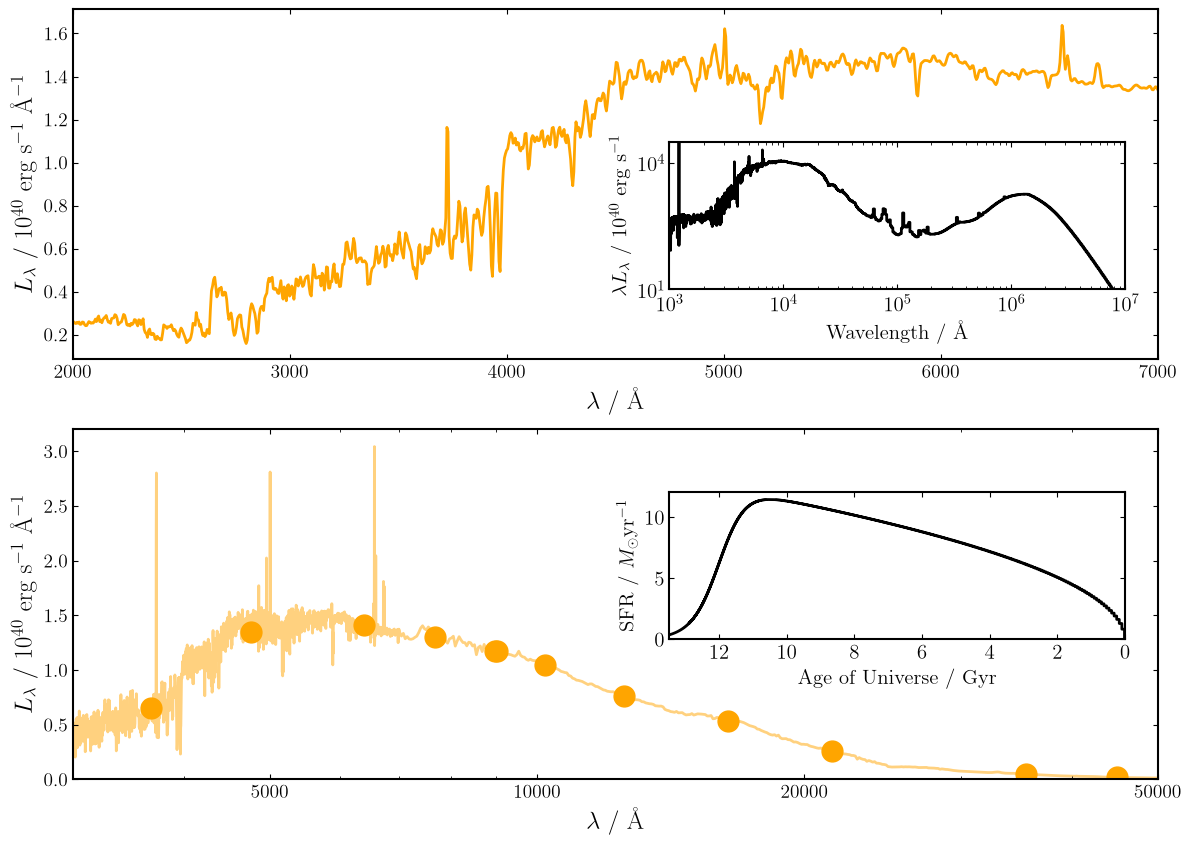

In [128]:
plt.close("all")

fig, (ax0, ax1) = plt.subplots(nrows = 2, ncols=1, figsize = (14, 10))
ax0.plot(wavelength, luminosity / 10**40, color = "orange")
ax0.set_xlim(np.min(wavelength), np.max(wavelength))
ax0.set_xlabel(r"$\lambda$ / \AA")
ax0.set_ylabel(r"$L_\lambda\ /\ 10^{40}$ erg s$^{-1}$ \AA$^{-1}$")

ax_lam = ax0.inset_axes([0.55, 0.2, 0.42, 0.42])
ax_lam.step(model.wavelengths, lambda_Llam/10**40, where="mid", color="black")
ax_lam.set_xscale('log')
ax_lam.set_yscale('log')
ax_lam.set_xlim(1e3, 1e7)
ax_lam.set_ylim(10, 3e4)
ax_lam.set_xlabel(r'Wavelength / $\textrm{\AA}$', fontsize = 15)
ax_lam.set_ylabel(r'$\lambda L_{\lambda}$ / $10^{40}$ erg s$^{-1}$', fontsize = 15)
ax_lam.tick_params(labelsize = 15)

ax1.plot(wavs, full_spec / 10**40, color = "orange", alpha = 0.5, zorder = 1)
ax1.plot(filter_eff_wavs, photometry / 10**40, marker = 'o', color = "orange", linestyle="none", markersize= 15, zorder = 2)
ax1.set_xscale('log')
ax1.set_xlim(3000, 50000)
ax1.set_ylim(0, 3.2)
ax1.set_xticks([5000, 10000, 20000, 50000])
ax1.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax1.xaxis.set_minor_formatter(ticker.NullFormatter())
ax1.set_xlabel(r"$\lambda$ / \AA")
ax1.set_ylabel(r"$L_\lambda\ /\ 10^{40}$ erg s$^{-1}$ \AA$^{-1}$")

ax_sfh = ax1.inset_axes([0.55, 0.4, 0.42, 0.42])
ax_sfh.step(t_form_gyr, SFR_bin, where="mid", color="black")
ax_sfh.set_xlim(age_universe* 10**(-9), 0)
ax_sfh.set_ylim(bottom=0)
ax_sfh.set_xlabel('Age of Universe / Gyr', fontsize = 15)
ax_sfh.set_ylabel(r'SFR / $M_\odot \mathrm{yr^{-1}}$', fontsize = 15)
ax_sfh.tick_params(labelsize = 15)
os.mkdir("figures")
fig.savefig("figures/fig1_reproduction.pdf")